## 2.6.  Embedding Görselleştirme

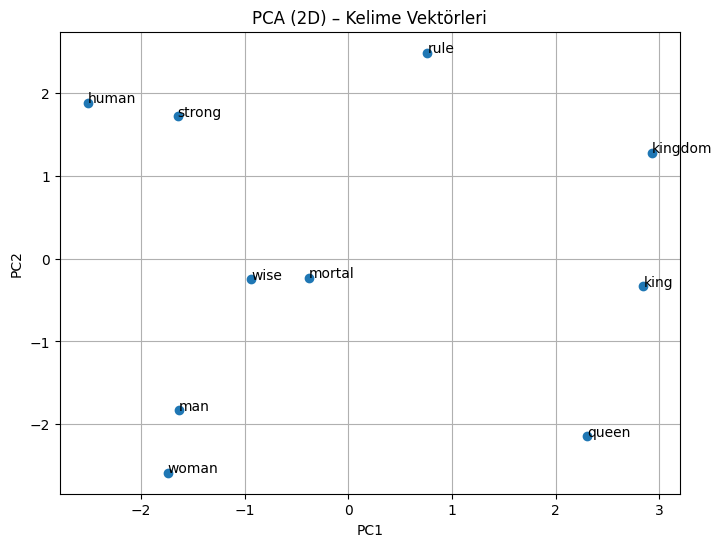

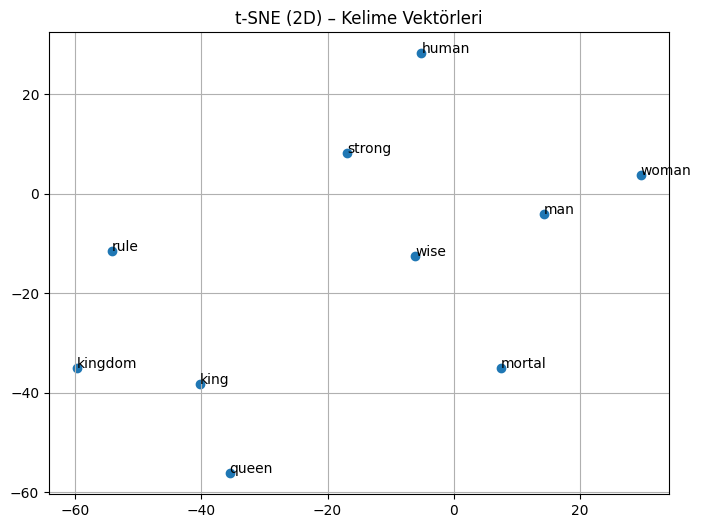

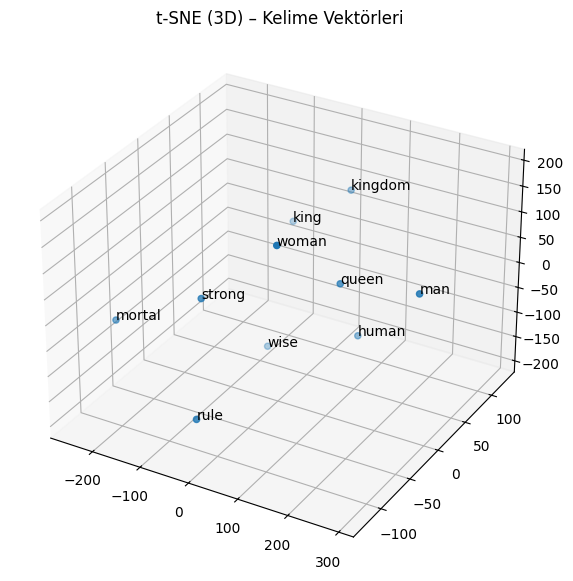

In [2]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import gensim.downloader as api

# GloVe modelini indir ve yükle (50 boyutlu embedding vektörleri)
glove_model = api.load("glove-wiki-gigaword-50")
# ✅ Model seçenekleri: word2vec_model, fasttext_model, glove_model
model =  glove_model #model #glove_model #fasttext_model #[ glove_model, model ]  # buraya model adını değiştirerek test edebilirsin

# Görselleştirilecek kelimeler (hepsi modelde olmalı)
#glove words = ["king", "queen", "man", "woman", "strong", "wise", "human", "rule", "mortal", "power", "kingdom"]
words = ["king", "queen", "man", "woman", "strong", "wise", "human", "rule", "mortal",  "kingdom"]


# Vektörleri topla
#glove_model.most_similar("king")
# word_vectors = np.array([model.wv[word] for word in words])
word_vectors = np.array([glove_model[word] for word in words])

# 1️⃣ PCA – 2D Görselleştirme
pca = PCA(n_components=2)
pca_result = pca.fit_transform(word_vectors)

plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, xy=(pca_result[i, 0], pca_result[i, 1]))
plt.title("PCA (2D) – Kelime Vektörleri")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# 2️⃣ t-SNE – 2D Görselleştirme
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_result = tsne.fit_transform(word_vectors)

plt.figure(figsize=(8, 6))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, xy=(tsne_result[i, 0], tsne_result[i, 1]))
plt.title("t-SNE (2D) – Kelime Vektörleri")
plt.grid(True)
plt.show()

# 3️⃣ t-SNE – 3D Görselleştirme
tsne_3d = TSNE(n_components=3, perplexity=5, random_state=42)
tsne_3d_result = tsne_3d.fit_transform(word_vectors)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(tsne_3d_result[:, 0], tsne_3d_result[:, 1], tsne_3d_result[:, 2])
for i, word in enumerate(words):
    ax.text(tsne_3d_result[i, 0], tsne_3d_result[i, 1], tsne_3d_result[i, 2], word)
ax.set_title("t-SNE (3D) – Kelime Vektörleri")
plt.show()


**Kazanımlar:**

PCA: Varyansın en yüksek olduğu iki bileşen üzerinden lineer projeksiyon.

t-SNE: Lokal semantik kümelenmeleri gösteren daha sezgisel bir projeksiyon.

3D t-SNE: Daha yüksek boyutta (ör. 50d, 100d) vektörlerin topolojisini görselleştirme imkânı.

